In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
55,24,55000,0
21,47,49000,1
272,60,42000,1
226,36,126000,1
349,38,61000,0


In [6]:
df.shape

(400, 3)

In [9]:
x_train , x_test , y_train, y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],
                                                      test_size=0.3,random_state=0)

In [15]:
x_train.head(2)

,Age,EstimatedSalary
92,26,15000
223,60,102000


In [17]:
y_train.head()

92     0
223    1
234    0
232    1
377    0
Name: Purchased, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()
scaler.fit(x_train)
scaler.fit(x_test)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)


In [32]:
np.round(x_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69807.0
std,10.0,34641.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [34]:
np.round(x_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


Text(0.5, 1.0, 'After Scaling')

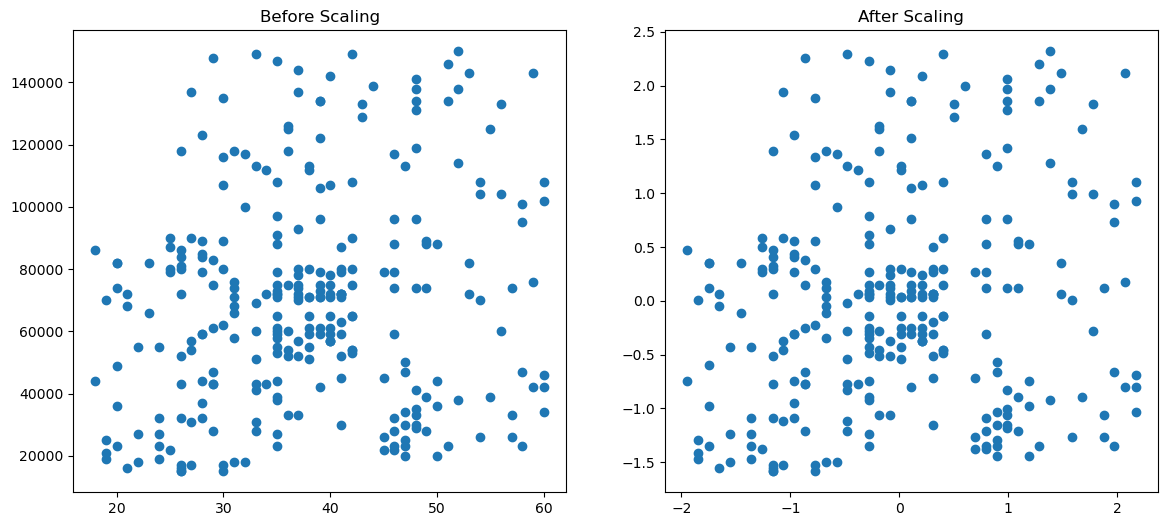

In [42]:
fig , (ax1 , ax2) = plt.subplots(ncols=2 , figsize = (14,6))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'])
ax2.set_title('After Scaling')

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [46]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [62]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

c:\Users\zhass\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [59]:
from sklearn.metrics import accuracy_score

In [63]:
print(f"Actual : ",accuracy_score(y_test , y_pred))
print(f"Scaled : ",accuracy_score(y_test , y_pred_scaled))

Actual :  0.875
Scaled :  0.8916666666666667
